In [12]:
"""
AAA_t_test2_multi_freq

Test the focused t-interpolation helper functions for several Matsubara frequencies.
Both SCE and WCE orders are set to 6.
"""

'\nAAA_t_test2_multi_freq\n\nTest the focused t-interpolation helper functions for several Matsubara frequencies.\nBoth SCE and WCE orders are set to 6.\n'

In [13]:
import sys
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt

from t_interpolation_workflow import (
    compute_exact_t,
    build_t_app_G_app,
)
from _bary_rational import AAA_tube

In [14]:
beta = 10.0
Ns = 2
Nw = 4 * int(beta)
Mat_fre = (2 * np.linspace(0, Nw - 1, Nw) + 1) * np.pi / beta
wn = np.append(-np.flip(Mat_fre), Mat_fre)
shift = 0

U = 4.0
T = 40.0
Nt = 15001
t_values_ED = np.linspace(0, T, Nt) + shift

sce_order = 2
wce_order = 8
epsilon = 1e-4

In [15]:
G_exact = compute_exact_t(t_values_ED, wn, U, beta)
print(G_exact.shape)

(15001, 80, 2, 2)


In [16]:
wn_id = [Nw-1, Nw-2,Nw-3, Nw-4, Nw-5]
print("Selected Matsubara indices:", wn_id)
print("Selected omegas:", wn[wn_id])

t_app_by_n = {}
G_app_by_n = {}
missing_t_domain_by_n = {}

for n in wn_id:
    t_app, G_app, missing_t_domain = build_t_app_G_app(
        sce_order=sce_order,
        wce_order=wce_order,
        baseline_G=G_exact[:, n],
        t_values=t_values_ED,
        epsilon=epsilon,
        wn=wn[n],
        U=U,
        beta=beta,
        aaa_resample=False
    )
    t_app_by_n[n] = t_app 
    G_app_by_n[n] = G_app
    missing_t_domain_by_n[n] = missing_t_domain
    print(f"n={n}, omega={wn[n]:.6g}, t_app shape={t_app.shape}, G_app shape={G_app.shape}, t range=({t_app.min():.4g}, {t_app.max():.4g})")

Selected Matsubara indices: [39, 38, 37, 36, 35]
Selected omegas: [-0.31415927 -0.9424778  -1.57079633 -2.19911486 -2.82743339]
SCE t domain: (0.0, 0.03733333333333333) WCE t domain: (2.5466666666666664, 40.0)
Missing t domain: (0.03733333333333333, 2.5466666666666664)
n=39, omega=-0.314159, t_app shape=(14061,), G_app shape=(14061, 2, 2), t range=(0, 40)
SCE t domain: (0.0, 0.042666666666666665) WCE t domain: (2.4906666666666664, 40.0)
Missing t domain: (0.042666666666666665, 2.4906666666666664)
n=38, omega=-0.942478, t_app shape=(14084,), G_app shape=(14084, 2, 2), t range=(0, 40)
SCE t domain: (0.0, 0.050666666666666665) WCE t domain: (2.2426666666666666, 40.0)
Missing t domain: (0.050666666666666665, 2.2426666666666666)
n=37, omega=-1.5708, t_app shape=(14180,), G_app shape=(14180, 2, 2), t range=(0, 40)
SCE t domain: (0.0, 0.064) WCE t domain: (2.048, 40.0)
Missing t domain: (0.064, 2.048)
n=36, omega=-2.19911, t_app shape=(14258,), G_app shape=(14258, 2, 2), t range=(0, 40)
SCE t

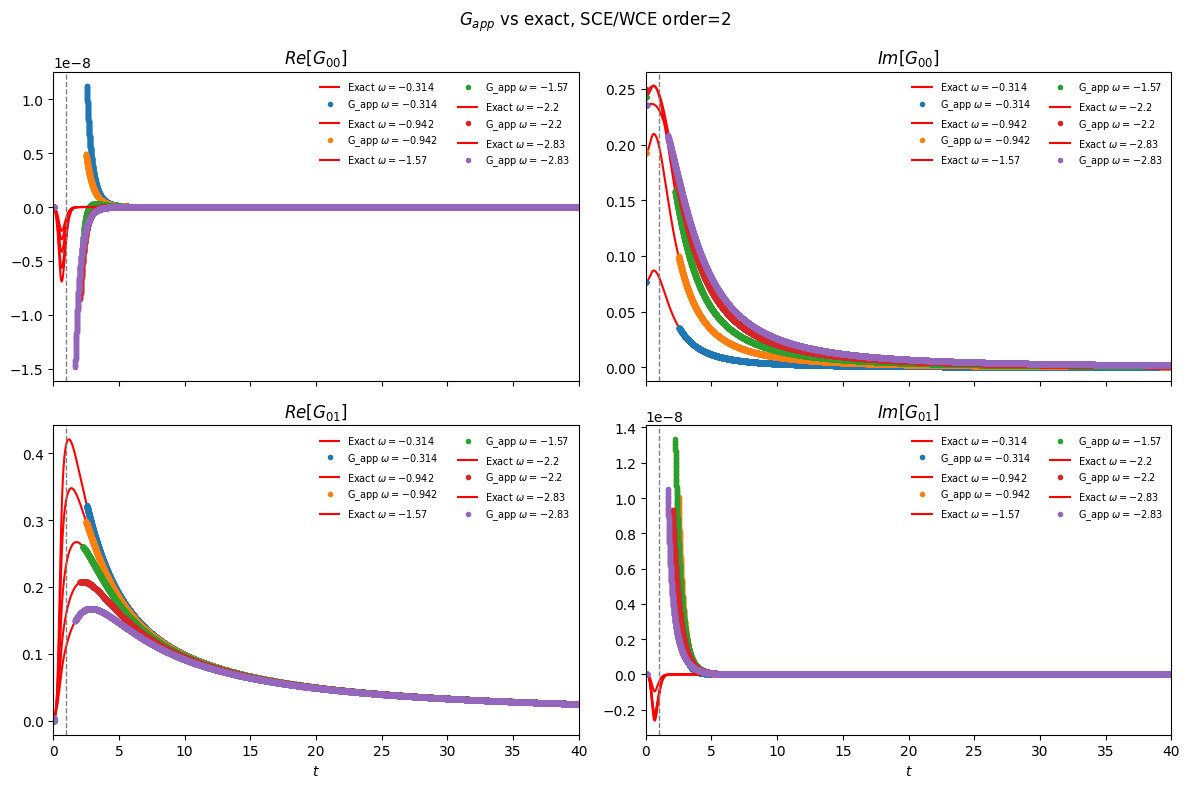

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

for n in wn_id:
    t_app = t_app_by_n[n] 
    G_app = G_app_by_n[n]

    axes[0, 0].plot(t_values_ED.real, G_exact[:, n, 0, 0].real, 'r-', label=rf"Exact $\omega={wn[n]:.3g}$")
    axes[0, 0].plot(t_app.real, G_app[:, 0, 0].real, ".", label=rf"G_app $\omega={wn[n]:.3g}$")

    axes[0, 1].plot(t_values_ED.real, G_exact[:, n, 0, 0].imag, 'r-', label=rf"Exact $\omega={wn[n]:.3g}$")
    axes[0, 1].plot(t_app.real, G_app[:, 0, 0].imag, ".", label=rf"G_app $\omega={wn[n]:.3g}$")

    axes[1, 0].plot(t_values_ED.real, G_exact[:, n, 0, 1].real, 'r-', label=rf"Exact $\omega={wn[n]:.3g}$")
    axes[1, 0].plot(t_app.real, G_app[:, 0, 1].real, ".", label=rf"G_app $\omega={wn[n]:.3g}$")

    axes[1, 1].plot(t_values_ED.real, G_exact[:, n, 0, 1].imag, 'r-', label=rf"Exact $\omega={wn[n]:.3g}$")
    axes[1, 1].plot(t_app.real, G_app[:, 0, 1].imag, ".", label=rf"G_app $\omega={wn[n]:.3g}$")

axes[0, 0].set_title(r"$Re[G_{00}]$")
axes[0, 1].set_title(r"$Im[G_{00}]$")
axes[1, 0].set_title(r"$Re[G_{01}]$")
axes[1, 1].set_title(r"$Im[G_{01}]$")

for ax in axes[1, :]:
    ax.set_xlabel(r"$t$")
for ax in axes.ravel():
    ax.set_xlim([0, T])
    ax.axvline(1, color="gray", linestyle="--", linewidth=1)
    ax.legend(frameon=False, fontsize=7, ncol=2)

fig.suptitle(r"$G_{app}$ vs exact, SCE/WCE order=%d" % sce_order)
fig.tight_layout()
plt.show()


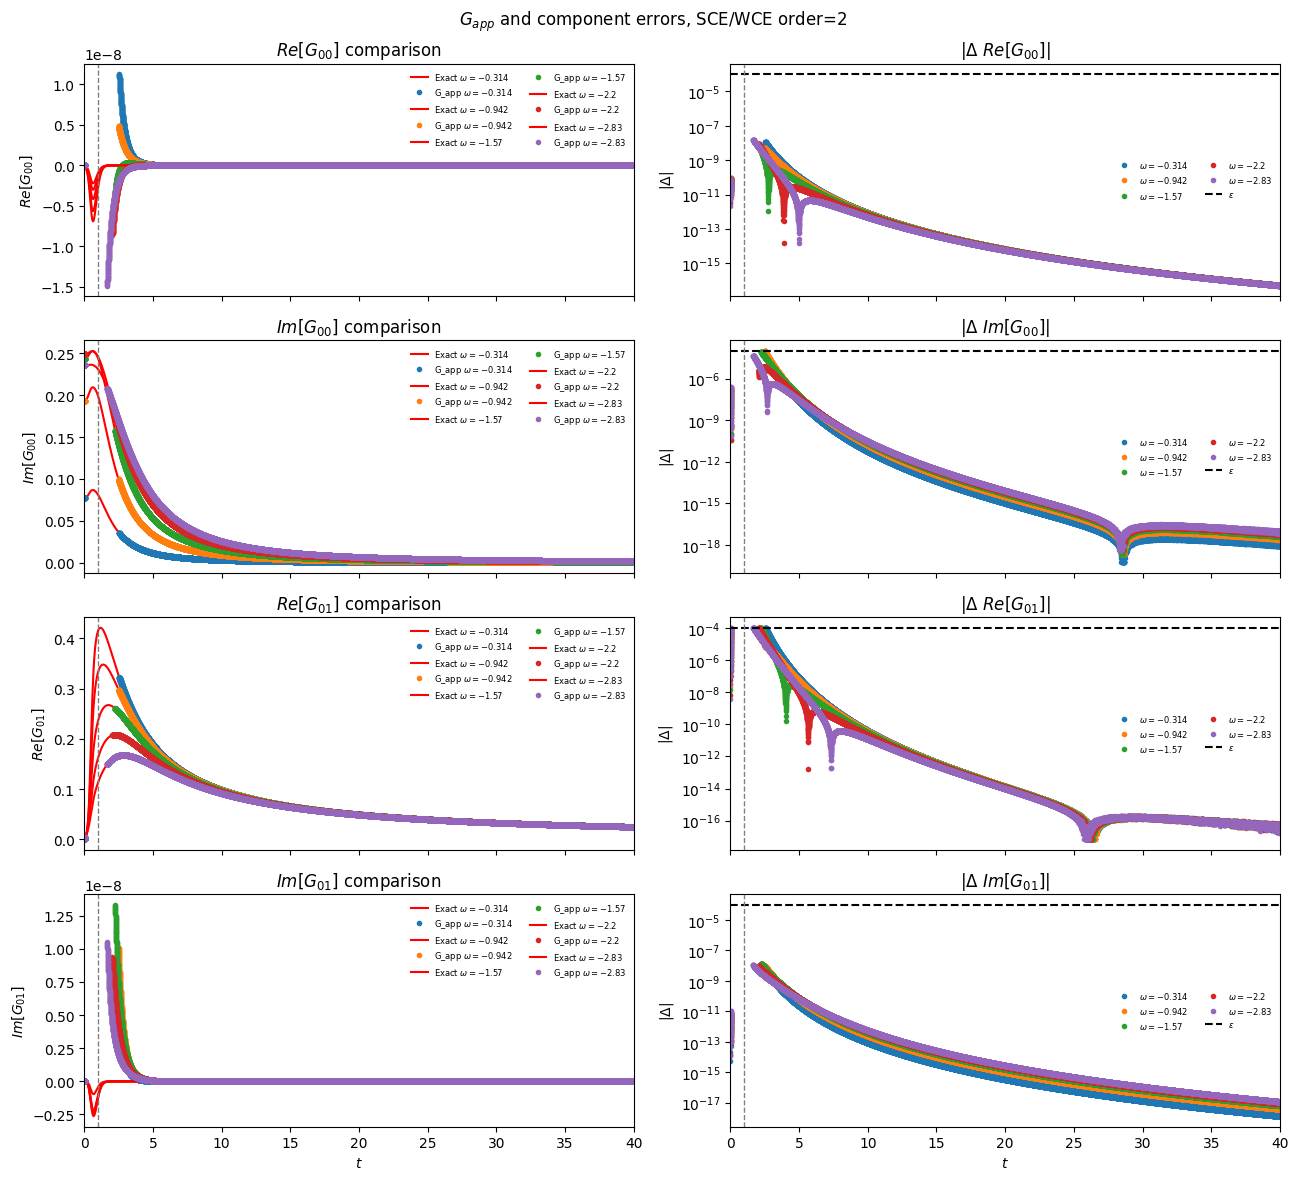

14405


In [18]:
fig, axes = plt.subplots(4, 2, figsize=(13, 12), sharex=True)

components = [
    (r"$Re[G_{00}]$", lambda G: G[:, 0, 0].real),
    (r"$Im[G_{00}]$", lambda G: G[:, 0, 0].imag),
    (r"$Re[G_{01}]$", lambda G: G[:, 0, 1].real),
    (r"$Im[G_{01}]$", lambda G: G[:, 0, 1].imag),
]

for n in wn_id:
    t_app = t_app_by_n[n]
    G_app = G_app_by_n[n]

    exact_at_app = np.zeros_like(G_app)
    for k, t in enumerate(t_app):
        idx = np.where(np.isclose(t_values_ED, t))[0]
        if idx.size:
            exact_at_app[k] = G_exact[idx[0], n]
        else:
            exact_at_app[k] = np.nan

    for row, (label, component) in enumerate(components):
        exact_component = component(G_exact[:, n])
        app_component = component(G_app)
        error_component = np.abs(component(G_app) - component(exact_at_app))

        axes[row, 0].plot(t_values_ED.real, exact_component, "r-", label=rf"Exact $\omega={wn[n]:.3g}$")
        axes[row, 0].plot(t_app.real, app_component, ".", label=rf"G_app $\omega={wn[n]:.3g}$")
        axes[row, 1].semilogy(t_app.real, error_component, ".", label=rf"$\omega={wn[n]:.3g}$")

for row, (label, _) in enumerate(components):
    axes[row, 0].set_title(label + " comparison")
    axes[row, 0].set_ylabel(label)
    axes[row, 1].set_title(r"$|\Delta$ " + label + r"$|$")
    axes[row, 1].set_ylabel(r"$|\Delta|$")
    axes[row, 1].axhline(epsilon, color="k", linestyle="--", label=r"$\epsilon$")

for ax in axes[-1, :]:
    ax.set_xlabel(r"$t$")
for ax in axes.ravel():
    ax.set_xlim([0, T])
    ax.axvline(1, color="gray", linestyle="--", linewidth=1)
    ax.legend(frameon=False, fontsize=6, ncol=2)

fig.suptitle(r"$G_{app}$ and component errors, SCE/WCE order=%d" % sce_order)
fig.tight_layout()
plt.show()

print(t_app.size)


In [19]:
### Multi-frequency G_app construction and AAA_tube interpolation test
wn_id = [Nw-1, Nw-2, Nw-3, Nw-4, Nw-5, Nw-10, Nw-20]
max_terms = 10
tube_delta = 0.2
tube_Ns = 100000
max_error = epsilon
tube_real_window = (-T, T)

G00_interp = np.zeros((t_values_ED.size, len(wn_id)), dtype=complex)
G01_interp = np.zeros((t_values_ED.size, len(wn_id)), dtype=complex)

G00_interp1 = np.zeros((t_values_ED.size, len(wn_id)), dtype=complex)
G01_interp1 = np.zeros((t_values_ED.size, len(wn_id)), dtype=complex)

G00_interp2 = np.zeros((t_values_ED.size, len(wn_id)), dtype=complex)
G01_interp2 = np.zeros((t_values_ED.size, len(wn_id)), dtype=complex)

t_app_by_n = {}
G_app_by_n = {}
missing_t_domain_by_n = {}

for col, n in enumerate(wn_id):
    print("n=", n, "omega=", wn[n])
    t_app, G_app, missing_t_domain = build_t_app_G_app(
        sce_order=sce_order,
        wce_order=wce_order,
        baseline_G=G_exact[:, n],
        t_values=t_values_ED,
        epsilon=epsilon,
        wn=wn[n],
        U=U,
        beta=beta,
        aaa_resample=False
    )
    t_app_by_n[n] = t_app
    G_app_by_n[n] = G_app
    missing_t_domain_by_n[n] = missing_t_domain

    r00 = AAA_tube(
        t_app, G_app[:, 0, 0], rtol=max_error, max_terms=max_terms,
        delta=tube_delta, Ns=tube_Ns, tube_real_window=tube_real_window,
    )
    r01 = AAA_tube(
        t_app, G_app[:, 0, 1], rtol=max_error, max_terms=max_terms,
        delta=tube_delta, Ns=tube_Ns, tube_real_window=tube_real_window,
    )
    G00_interp[:, col] = r00(np.linspace(0, T, Nt))
    G01_interp[:, col] = r01(np.linspace(0, T, Nt))
    G00_interp1[:, col] = r00(np.linspace(0, T, Nt)-1j*0.05)
    G01_interp1[:, col] = r01(np.linspace(0, T, Nt)-1j*0.05)
    G00_interp2[:, col] = r00(np.linspace(0, T, Nt)-1j*0.1)
    G01_interp2[:, col] = r01(np.linspace(0, T, Nt)-1j*0.1)

n= 39 omega= -0.3141592653589793
SCE t domain: (0.0, 0.03733333333333333) WCE t domain: (2.5466666666666664, 40.0)
Missing t domain: (0.03733333333333333, 2.5466666666666664)
AAA_tube final poles: [0.00868275-1.69301271j 0.00870143+1.69300803j 0.33727788-0.53486707j
 0.33723462+0.53483941j]
AAA_tube tube real interval: (-40.0, 40.0)
AAA_tube tube delta: 0.2
AAA_tube poles inside tube: []
AAA_tube maximum boundary |r(z)|: 0.10016151073010707
AAA_tube using best tube-safe iterate before max_terms.
AAA_tube final poles: [0.25920467-1.41549995j 0.25920502+1.4154997j ]
AAA_tube tube real interval: (-40.0, 40.0)
AAA_tube tube delta: 0.2
AAA_tube poles inside tube: []
AAA_tube maximum boundary |r(z)|: 0.3915888628491834
n= 38 omega= -0.9424777960769379
SCE t domain: (0.0, 0.042666666666666665) WCE t domain: (2.4906666666666664, 40.0)
Missing t domain: (0.042666666666666665, 2.4906666666666664)
AAA_tube final poles: [-0.00413486-1.81750091j -0.00413414+1.81750173j  0.20789294-0.75767333j
  0.2

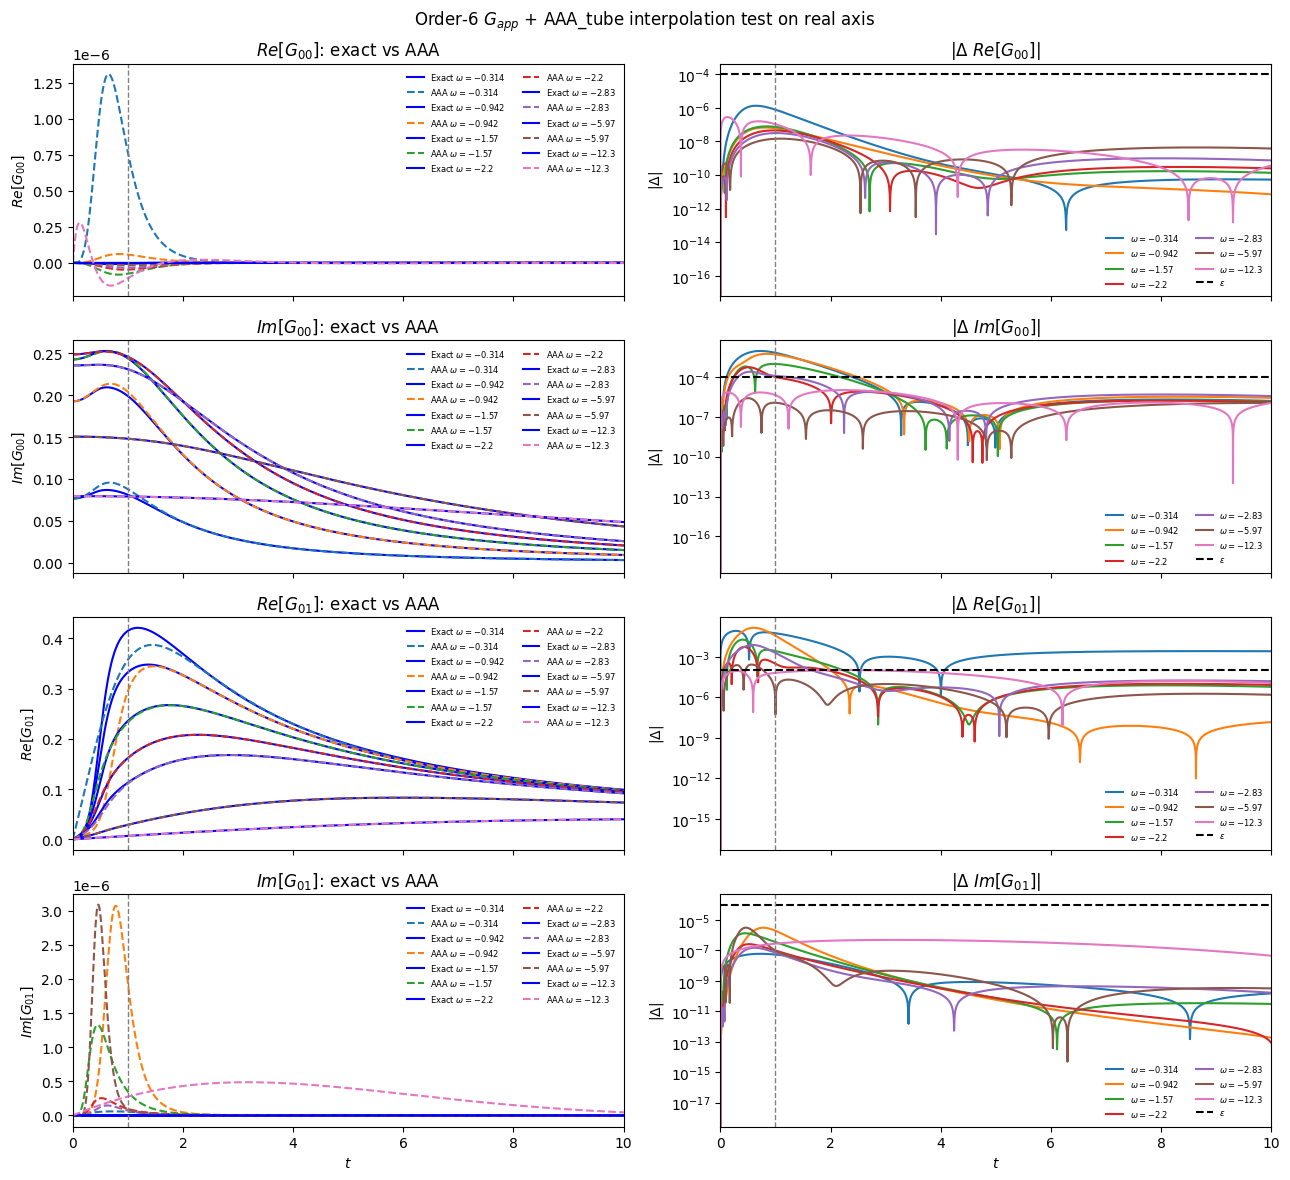

In [20]:
G_exact = compute_exact_t(t_values_ED.real, wn, U, beta)

def plot_aaa_component_comparison(t_plot, G_ref, G00_pred, G01_pred, title, T_plot=T):
    fig, axes = plt.subplots(4, 2, figsize=(13, 12), sharex=True)
    components = [
        (r"$Re[G_{00}]$", G_ref[:, :, 0, 0].real, G00_pred.real),
        (r"$Im[G_{00}]$", G_ref[:, :, 0, 0].imag, G00_pred.imag),
        (r"$Re[G_{01}]$", G_ref[:, :, 0, 1].real, G01_pred.real),
        (r"$Im[G_{01}]$", G_ref[:, :, 0, 1].imag, G01_pred.imag),
    ]

    for col, n in enumerate(wn_id):
        for row, (label, exact_component, aaa_component) in enumerate(components):
            axes[row, 0].plot(t_plot.real, exact_component[:, n], "b", label=rf"Exact $\omega={wn[n]:.3g}$")
            axes[row, 0].plot(t_plot.real, aaa_component[:, col], "--", label=rf"AAA $\omega={wn[n]:.3g}$")
            axes[row, 1].semilogy(
                t_plot.real,
                np.abs(exact_component[:, n] - aaa_component[:, col]),
                label=rf"$\omega={wn[n]:.3g}$",
            )

    for row, (label, _, _) in enumerate(components):
        axes[row, 0].set_title(label + r": exact vs AAA")
        axes[row, 0].set_ylabel(label)
        axes[row, 1].set_title(r"$|\Delta$ " + label + r"$|$")
        axes[row, 1].set_ylabel(r"$|\Delta|$")
        axes[row, 1].axhline(epsilon, color="k", linestyle="--", label=r"$\epsilon$")

    for ax in axes[-1, :]:
        ax.set_xlabel(r"$t$")
    for ax in axes.ravel():
        ax.set_xlim([0, T_plot])
        ax.axvline(1, color="gray", linestyle="--", linewidth=1)
        ax.axvline(t_values_ED.real.min(), color="0.35", linestyle=":", linewidth=1.2)
        ax.axvline(t_values_ED.real.max(), color="0.35", linestyle=":", linewidth=1.2)
        ax.legend(frameon=False, fontsize=6, ncol=2)

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

plot_aaa_component_comparison(
    t_values_ED.real,
    G_exact,
    G00_interp,
    G01_interp,
    r"Order-6 $G_{app}$ + AAA_tube interpolation test on real axis",
    T_plot = 10
)


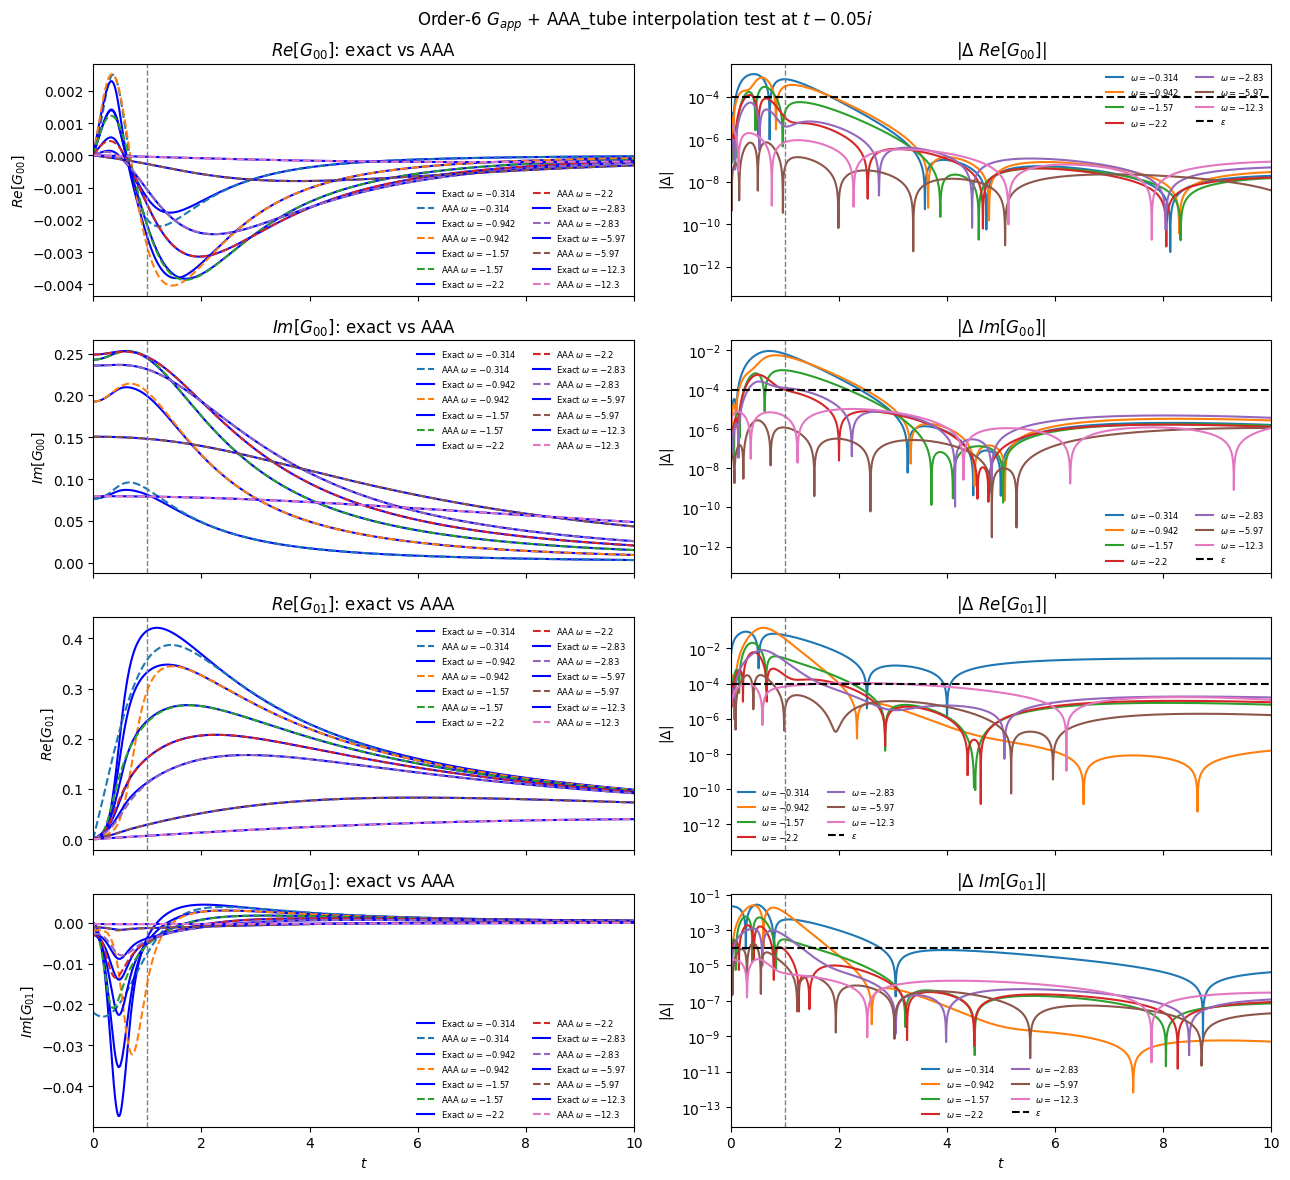

In [21]:
t_values1 = np.linspace(0, T, Nt) - 1j * 0.05
G_exact1 = compute_exact_t(t_values1, wn, U, beta)

plot_aaa_component_comparison(
    t_values1,
    G_exact1,
    G00_interp1,
    G01_interp1,
    r"Order-6 $G_{app}$ + AAA_tube interpolation test at $t-0.05i$",
    T_plot= 10
)

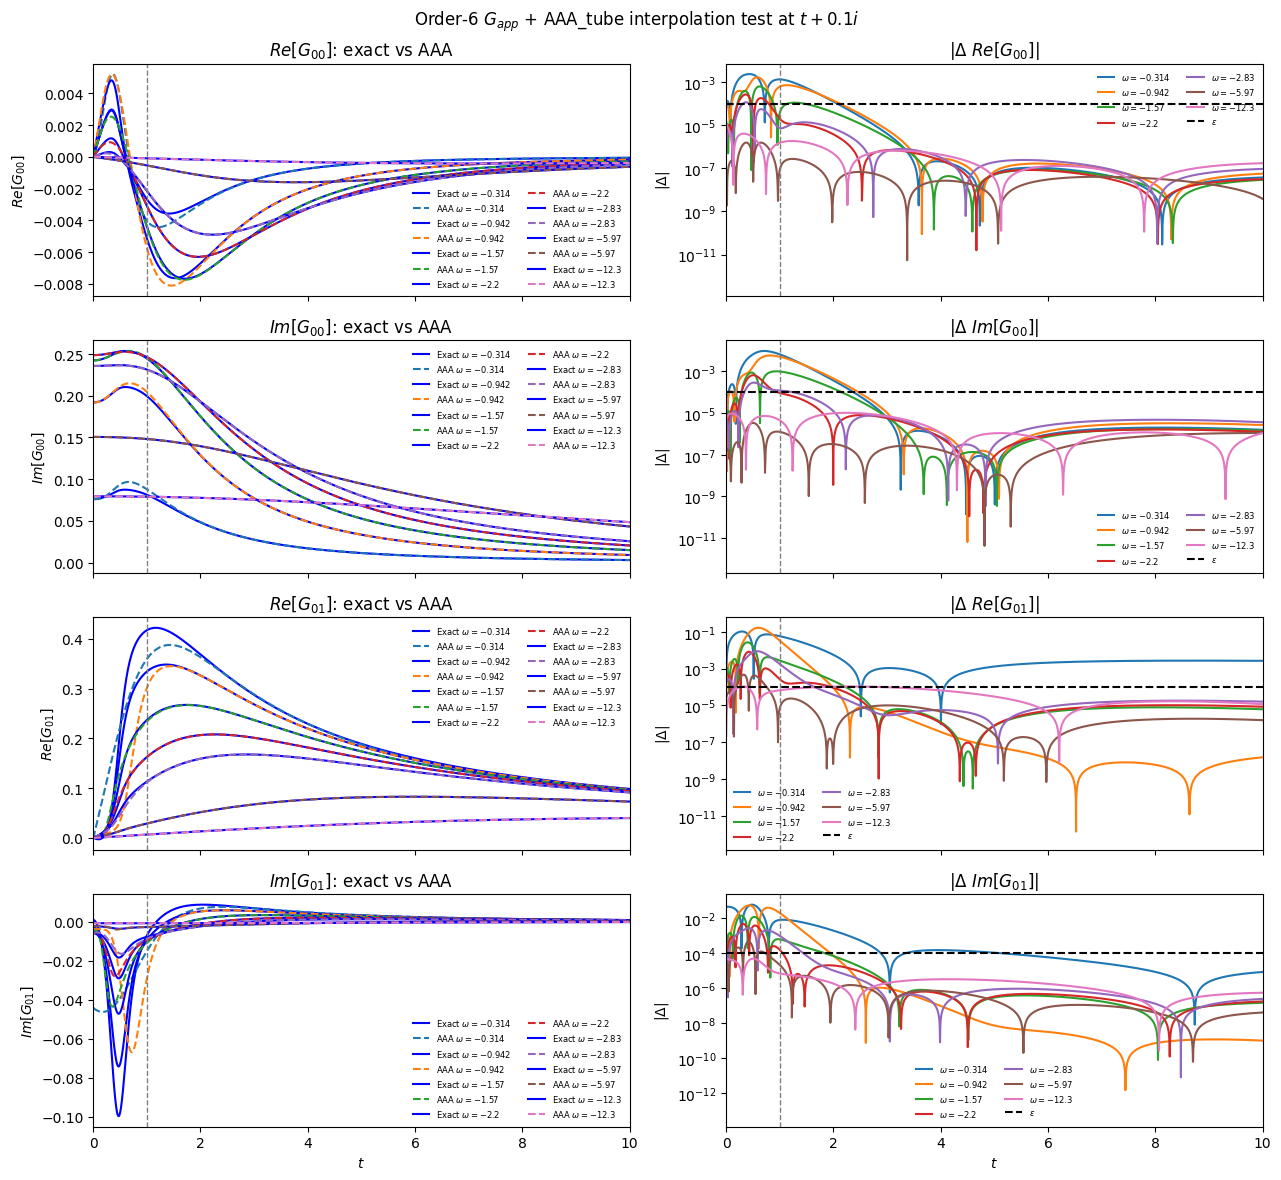

In [22]:
t_values2 = np.linspace(0, T, Nt) - 1j * 0.1
G_exact2 = compute_exact_t(t_values2, wn, U, beta)

plot_aaa_component_comparison(
    t_values2,
    G_exact2,
    G00_interp2,
    G01_interp2,
    r"Order-6 $G_{app}$ + AAA_tube interpolation test at $t+0.1i$",
    T_plot= 10
)